# High Fidelity Neural Network
Neural Network which uses HF dataset and exploits the High fidelity component of the MF model  

In [1]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax

from time import perf_counter
import pandas
import os
import keras
import tensorflow as tf


from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)

True

In [2]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

# Data preparation

In [3]:
file_path_HF = "../DATA_reaction_diffusion_test_case/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

U_HF_test = U_HF_test[:, -1, 44,44]

reaction_HF_test = normalization(reaction_HF_test)
U_HF_test = normalization(U_HF_test)


reaction_HF_test_original=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]
U_HF_test_original=U_HF_test


In [5]:
noise_stddev1=[0.005,0.003, 0.01, 0.003]
noise_stddev2=[0.01,0.005,0.02,0.005]
(U_HF_test,reaction_HF_test)=add_noise(noise_stddev1,noise_stddev2,reaction_HF_test,U_HF_test.reshape(-1,1))
reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]

In [6]:
permutation = np.random.permutation(len(reaction_HF_test))

NepoHF = 8000  # number of epochs for second NN: NN_HF
Nhf = 100

reaction_HF = reaction_HF_test[permutation,:][0:Nhf,:]
U_HF = U_HF_test[permutation][0:Nhf]

# Neural Network

In [7]:
name = "HF"  # I leave the same NN,  even if we use HF data instead of LF
K.clear_session()
best_params = {
    'kernel_init': 'glorot_uniform',
    'l2weight': 0.03711750915883216,
    'lr': 0.024244197598433916,
    'opt': 'Adamax'
}



HF Model:
The function training took 176.361972 seconds.


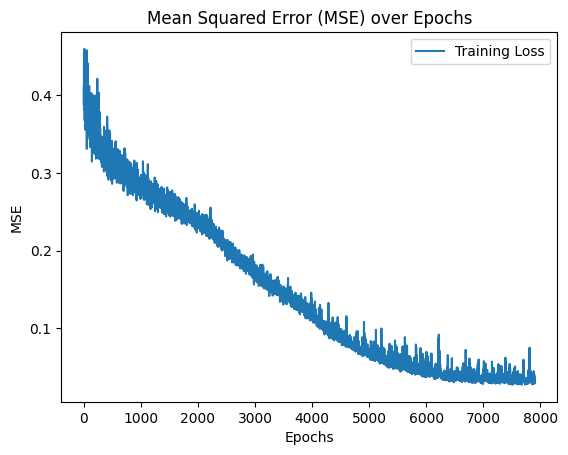

Test MSE: 0.05539038777067127
R^2: 0.5106803770513463


In [9]:
####################    NN training and PREDICTION    #######################

print("\nHF Model:")

definition_HF={
        "network_type": "LF",
        "params": best_params,
        "data_train": reaction_HF,
        "output_train": U_HF,
        "N": NepoHF,
        "n": Nhf,
        "train": True,
        "do_HPO": False,
        "verbose": False
    }

model= NetworkFactory.build_network(**definition_HF)
UHF = model.prediction(reaction_HF_test_original)

(mse_HF,R_HF) = model.performance(reaction_HF_test_original,U_HF_test_original)


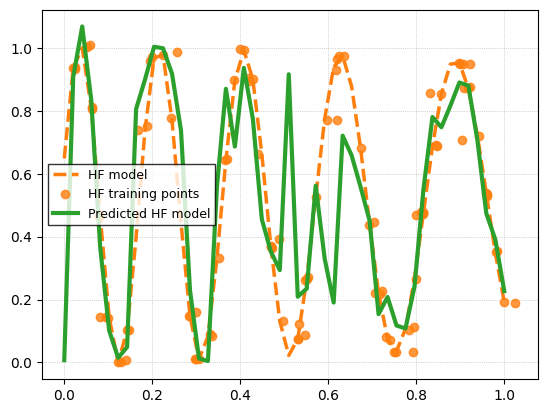

In [10]:
plot_results(reaction_HF_test_original,U_HF_test_original, model.prediction(reaction_HF_test_original), "HF",  reaction_HF,  U_HF, "#FF7F0E", "#2CA02C", "HF model", "Predicted HF model")
